# MLP Default Prediction

This notebook trains a multilayer perceptron to predict `default payment next month` from the credit-card client dataset.

Model choice: for this 30,000-row tabular dataset, a medium MLP is a good neural baseline. Very large neural networks usually do not help much on tabular data and can overfit quickly. Strong classical baselines such as logistic regression, random forests, XGBoost/LightGBM/CatBoost are often competitive or better, but this notebook focuses on a well-sized MLP.

## Shared MLP Code

The shared MLP architecture and training decisions are imported from `src/credit_mlp.py` in the first code cell. In this notebook, the shared trainer is imported as `train_global_mlp`, so global and client training use the same base implementation.


In [15]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

import torch
from torch import nn

# Shared model/training code comes from src/credit_mlp.py.
try:
    from credit_data import prepare_feature_sets
    from credit_mlp import (
        DEFAULT_BATCH_SIZE,
        DEFAULT_LEARNING_RATE,
        DEFAULT_MAX_EPOCHS,
        DEFAULT_PATIENCE,
        DEFAULT_SEED,
        DEFAULT_WEIGHT_DECAY,
        CreditDefaultMLP,
        make_loader,
        save_mlp_config,
        normalize_mlp_config,
        load_mlp_config,
        predict_proba as shared_predict_proba,
        set_seed,
        train_credit_default_mlp as train_global_mlp,
    )
except ModuleNotFoundError:
    import sys

    sys.path.append(str(Path.cwd() / "src"))
    from credit_data import prepare_feature_sets
    from credit_mlp import (
        DEFAULT_BATCH_SIZE,
        DEFAULT_LEARNING_RATE,
        DEFAULT_MAX_EPOCHS,
        DEFAULT_PATIENCE,
        DEFAULT_SEED,
        DEFAULT_WEIGHT_DECAY,
        CreditDefaultMLP,
        make_loader,
        save_mlp_config,
        normalize_mlp_config,
        load_mlp_config,
        predict_proba as shared_predict_proba,
        set_seed,
        train_credit_default_mlp as train_global_mlp,
    )

SEED = DEFAULT_SEED
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    for idx in range(torch.cuda.device_count()):
        print(idx, torch.cuda.get_device_name(idx))


Device: cuda
CUDA device count: 1
0 NVIDIA A40


In [16]:
DATA_PATHS = [
    Path("../data/default_of_credit_card_clients.xls"),
    Path("data/default_of_credit_card_clients.xls"),
]
DATA_PATH = next(path for path in DATA_PATHS if path.exists())

df = pd.read_excel(DATA_PATH, header=1)
target_col = "default payment next month"

print(DATA_PATH)
print(df.shape)
df.head()


../data/default_of_credit_card_clients.xls
(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Feature Plan

This notebook compares two versions of the input data for the MLP: the original credit-card features and a second version with extra behavioral summaries. `ID` is removed because it only labels each row and should not help the model predict default risk.

The engineered features summarize repayment delays, bill amounts, payment amounts, credit-limit utilization, and recent bill changes. These features are added to make repeated monthly patterns easier for the model to learn.

Categorical columns are one-hot encoded so the network can use them as separate indicator variables, while numeric columns are standardized because MLPs train more reliably when inputs are on similar scales. Both feature sets use the same stratified train, validation, and test split so any performance difference is due to the features rather than different data partitions.


In [17]:
feature_sets = prepare_feature_sets(df, target_col=target_col, seed=SEED)

ACTIVE_FEATURE_SET = "engineered"
active_data = feature_sets[ACTIVE_FEATURE_SET]

X_train = active_data["X_train"]
X_val = active_data["X_val"]
X_test = active_data["X_test"]
y_train = active_data["y_train"]
y_val = active_data["y_val"]
y_test = active_data["y_test"]
numeric_cols = active_data["numeric_cols"]
preprocess = active_data["preprocess"]

for name, data_bundle in feature_sets.items():
    print(
        f"{name}: Train {data_bundle['X_train'].shape}, "
        f"Val {data_bundle['X_val'].shape}, Test {data_bundle['X_test'].shape}, "
        f"engineered={data_bundle['use_feature_engineering']}"
    )
print("Active feature set:", ACTIVE_FEATURE_SET)
print("Default rate train:", y_train.mean().round(4))


baseline: Train (21000, 91), Val (4500, 91), Test (4500, 91), engineered=False
engineered: Train (21000, 105), Val (4500, 105), Test (4500, 105), engineered=True
Active feature set: engineered
Default rate train: 0.2212


In [18]:
def activate_feature_set(feature_set_name):
    global active_data, X_train, X_val, X_test, y_train, y_val, y_test, numeric_cols, preprocess

    active_data = feature_sets[feature_set_name]
    X_train = active_data["X_train"]
    X_val = active_data["X_val"]
    X_test = active_data["X_test"]
    y_train = active_data["y_train"]
    y_val = active_data["y_val"]
    y_test = active_data["y_test"]
    numeric_cols = active_data["numeric_cols"]
    preprocess = active_data["preprocess"]
    return active_data


batch_size = DEFAULT_BATCH_SIZE
activate_feature_set(ACTIVE_FEATURE_SET)

train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=batch_size, shuffle=False)
test_loader = make_loader(X_test, y_test, batch_size=batch_size, shuffle=False)


## Hyperparameter Search

Accuracy is not enough for this imbalanced binary problem. This section tries several MLP configurations and selects models based on validation metrics for the `default = 1` class.

The most important metrics here are:

- `val_f1`: balance between default precision and default recall
- `val_recall`: how many true defaults are found
- `val_precision`: how many predicted defaults are actually defaults
- `val_roc_auc`: ranking quality across thresholds
- `val_pr_auc`: precision-recall quality for the minority class


In [19]:
class TunableCreditMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), dropout=0.2, use_batch_norm=False):
        super().__init__()
        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def probabilities_for_model(model_to_eval, loader):
    model_to_eval.eval()
    probs = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model_to_eval(xb.to(device))
            probs.append(torch.sigmoid(logits).cpu().numpy().ravel())
            targets.append(yb.numpy().ravel())
    return np.concatenate(targets), np.concatenate(probs)


def best_threshold_metrics(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 181)
    rows = []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
        })
    metrics = pd.DataFrame(rows)
    best = metrics.sort_values(["f1", "recall"], ascending=False).iloc[0]
    return best


In [20]:
def train_one_config(config, data_bundle, max_epochs=25, patience=5, verbose=False):
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    X_train_cfg = data_bundle["X_train"]
    X_val_cfg = data_bundle["X_val"]
    y_train_cfg = data_bundle["y_train"]
    y_val_cfg = data_bundle["y_val"]

    train_loader_cfg = make_loader(X_train_cfg, y_train_cfg, config["batch_size"], shuffle=True)
    val_loader_cfg = make_loader(X_val_cfg, y_val_cfg, config["batch_size"], shuffle=False)

    candidate = TunableCreditMLP(
        input_dim=X_train_cfg.shape[1],
        hidden_dims=config["hidden_dims"],
        dropout=config["dropout"],
        use_batch_norm=config["batch_norm"],
    ).to(device)

    positive_count = float(y_train_cfg.sum())
    negative_count = float(len(y_train_cfg) - y_train_cfg.sum())
    pos_weight_local = torch.tensor([negative_count / positive_count], dtype=torch.float32, device=device)

    if config["use_pos_weight"]:
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_local)
    else:
        loss_fn = nn.BCEWithLogitsLoss()

    opt = torch.optim.AdamW(candidate.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

    best_score = -np.inf
    best_state = None
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        candidate.train()
        for xb, yb in train_loader_cfg:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = candidate(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        y_val_true_cfg, y_val_prob_cfg = probabilities_for_model(candidate, val_loader_cfg)
        val_auc = roc_auc_score(y_val_true_cfg, y_val_prob_cfg)
        threshold_metrics = best_threshold_metrics(y_val_true_cfg, y_val_prob_cfg)
        score = threshold_metrics["f1"]

        if verbose:
            print(f"epoch {epoch:02d} val_auc={val_auc:.4f} val_f1={score:.4f}")

        if score > best_score:
            best_score = score
            best_state = {key: value.detach().cpu().clone() for key, value in candidate.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    candidate.load_state_dict(best_state)
    y_val_true_cfg, y_val_prob_cfg = probabilities_for_model(candidate, val_loader_cfg)
    threshold_metrics = best_threshold_metrics(y_val_true_cfg, y_val_prob_cfg)

    return {
        **config,
        "epochs": epoch,
        "input_dim": X_train_cfg.shape[1],
        "best_threshold": float(threshold_metrics["threshold"]),
        "val_f1": float(threshold_metrics["f1"]),
        "val_precision": float(threshold_metrics["precision"]),
        "val_recall": float(threshold_metrics["recall"]),
        "val_roc_auc": float(roc_auc_score(y_val_true_cfg, y_val_prob_cfg)),
        "val_pr_auc": float(average_precision_score(y_val_true_cfg, y_val_prob_cfg)),
        "state_dict": best_state,
    }


### Search Grid

This grid is intentionally modest so it can run on CPU. Increase it later if you want a slower but broader search.

In [21]:
search_space = {
    "hidden_dims": [(64, 32), (128, 64), (256, 128, 64)],
    "dropout": [0.1, 0.2, 0.3],
    "batch_norm": [False, True],
    "batch_size": [128, 512],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-4],
    "use_pos_weight": [True],
}

configs = [
    dict(zip(search_space.keys(), values))
    for values in product(*search_space.values())
]

FEATURE_SETS_TO_COMPARE = ["baseline", "engineered"]
print(f"Training {len(configs)} configurations for each of {FEATURE_SETS_TO_COMPARE}")

search_results = []
best_result = None

for feature_set_name in FEATURE_SETS_TO_COMPARE:
    data_bundle = feature_sets[feature_set_name]
    print(f"\nFeature set: {feature_set_name} | input_dim={data_bundle['X_train'].shape[1]}")

    for idx, config in enumerate(configs, start=1):
        print(f"[{idx:02d}/{len(configs)}] {config}")
        result = train_one_config(config, data_bundle, max_epochs=25, patience=5)
        result["feature_set"] = feature_set_name
        result["use_feature_engineering"] = data_bundle["use_feature_engineering"]
        search_results.append(result)
        print(
            f"    val_f1={result['val_f1']:.4f} "
            f"precision={result['val_precision']:.4f} "
            f"recall={result['val_recall']:.4f} "
            f"auc={result['val_roc_auc']:.4f} "
            f"threshold={result['best_threshold']:.3f}"
        )

        if best_result is None or result["val_f1"] > best_result["val_f1"]:
            best_result = result

search_results_df = pd.DataFrame([
    {key: value for key, value in result.items() if key != "state_dict"}
    for result in search_results
]).sort_values(["val_f1", "val_recall", "val_roc_auc"], ascending=False)

comparison_df = (
    search_results_df
    .sort_values(["feature_set", "val_f1", "val_recall", "val_roc_auc"], ascending=[True, False, False, False])
    .groupby("feature_set", as_index=False)
    .head(1)
    .sort_values(["val_f1", "val_recall", "val_roc_auc"], ascending=False)
)

comparison_df[[
    "feature_set",
    "input_dim",
    "val_f1",
    "val_precision",
    "val_recall",
    "val_roc_auc",
    "val_pr_auc",
    "best_threshold",
    "hidden_dims",
    "dropout",
    "batch_norm",
    "batch_size",
    "lr",
]]


Training 72 configurations for each of ['baseline', 'engineered']

Feature set: baseline | input_dim=91
[01/72] {'hidden_dims': (64, 32), 'dropout': 0.1, 'batch_norm': False, 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'use_pos_weight': True}
    val_f1=0.5403 precision=0.5112 recall=0.5729 auc=0.7765 threshold=0.550
[02/72] {'hidden_dims': (64, 32), 'dropout': 0.1, 'batch_norm': False, 'batch_size': 128, 'lr': 0.0005, 'weight_decay': 0.0001, 'use_pos_weight': True}
    val_f1=0.5411 precision=0.5366 recall=0.5457 auc=0.7762 threshold=0.595
[03/72] {'hidden_dims': (64, 32), 'dropout': 0.1, 'batch_norm': False, 'batch_size': 512, 'lr': 0.001, 'weight_decay': 0.0001, 'use_pos_weight': True}
    val_f1=0.5438 precision=0.5322 recall=0.5558 auc=0.7772 threshold=0.585
[04/72] {'hidden_dims': (64, 32), 'dropout': 0.1, 'batch_norm': False, 'batch_size': 512, 'lr': 0.0005, 'weight_decay': 0.0001, 'use_pos_weight': True}
    val_f1=0.5422 precision=0.5387 recall=0.5457 auc=0.7763 th

,feature_set,input_dim,val_f1,val_precision,val_recall,val_roc_auc,val_pr_auc,best_threshold,hidden_dims,dropout,batch_norm,batch_size,lr
120,engineered,105,0.546129,0.506885,0.591960,0.778318,0.545218,0.505,"(256, 128, 64)",0.1,False,128,0.0010
13,baseline,91,0.545278,0.528801,0.562814,0.776086,0.540693,0.545,"(64, 32)",0.2,True,128,0.0005


In [22]:
ignored_result_keys = {
    "state_dict",
    "epochs",
    "input_dim",
    "best_threshold",
    "val_f1",
    "val_precision",
    "val_recall",
    "val_roc_auc",
    "val_pr_auc",
    "feature_set",
    "use_feature_engineering",
}
best_config = {key: value for key, value in best_result.items() if key not in ignored_result_keys}
best_feature_set = best_result["feature_set"]
best_data = feature_sets[best_feature_set]

print("Best feature set:", best_feature_set)
print("Best config:")
print(best_config)
print("Best validation threshold:", best_result["best_threshold"])

best_model = TunableCreditMLP(
    input_dim=best_data["X_train"].shape[1],
    hidden_dims=best_config["hidden_dims"],
    dropout=best_config["dropout"],
    use_batch_norm=best_config["batch_norm"],
).to(device)
best_model.load_state_dict(best_result["state_dict"])

test_loader_best = make_loader(best_data["X_test"], best_data["y_test"], best_config["batch_size"], shuffle=False)
y_test_true_best, y_test_prob_best = probabilities_for_model(best_model, test_loader_best)
y_test_pred_best = (y_test_prob_best >= best_result["best_threshold"]).astype(int)

print("Test ROC-AUC:", round(roc_auc_score(y_test_true_best, y_test_prob_best), 4))
print("Test PR-AUC:", round(average_precision_score(y_test_true_best, y_test_prob_best), 4))
print("Test accuracy:", round(accuracy_score(y_test_true_best, y_test_pred_best), 4))
print("Test F1:", round(f1_score(y_test_true_best, y_test_pred_best), 4))
print("Test precision:", round(precision_score(y_test_true_best, y_test_pred_best), 4))
print("Test recall:", round(recall_score(y_test_true_best, y_test_pred_best), 4))
print()
print(classification_report(y_test_true_best, y_test_pred_best, target_names=["no default", "default"]))
print("Confusion matrix:")
print(confusion_matrix(y_test_true_best, y_test_pred_best))


Best feature set: engineered
Best config:
{'hidden_dims': (256, 128, 64), 'dropout': 0.1, 'batch_norm': False, 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'use_pos_weight': True}
Best validation threshold: 0.5049999999999999
Test ROC-AUC: 0.7765
Test PR-AUC: 0.5574
Test accuracy: 0.7816
Test F1: 0.5422
Test precision: 0.5056
Test recall: 0.5843

              precision    recall  f1-score   support

  no default       0.88      0.84      0.86      3504
     default       0.51      0.58      0.54       996

    accuracy                           0.78      4500
   macro avg       0.69      0.71      0.70      4500
weighted avg       0.79      0.78      0.79      4500

Confusion matrix:
[[2935  569]
 [ 414  582]]


### Faster or Larger Search

If this is too slow, reduce the grid to fewer values or lower `max_epochs`. If you want a stronger search, add more learning rates such as `2e-3` and `1e-4`, more batch sizes such as `64` and `256`, and try `use_pos_weight=False` to see whether threshold tuning alone works better.

## Model

This is intentionally not huge. The dataset has only 30k rows, so a network like `256 -> 128 -> 64 -> 32` is already expressive enough. Batch normalization and dropout help reduce overfitting.

In [23]:
# Pick which feature set to use for the final shared MLP below.
# Use "baseline" for the original features or "engineered" for original + engineered features.
ACTIVE_FEATURE_SET = best_feature_set if "best_feature_set" in globals() else "engineered"
activate_feature_set(ACTIVE_FEATURE_SET)

MODEL_DIR = Path("../models")
MODEL_CONFIG_PATH = MODEL_DIR / "credit_default_mlp_config.json"

if "best_config" in globals():
    shared_model_config = normalize_mlp_config(best_config)
    print("Using grid-search best config from this notebook run.")
else:
    shared_model_config = load_mlp_config(MODEL_CONFIG_PATH)
    print("Using saved/default shared config:", MODEL_CONFIG_PATH)

batch_size = shared_model_config["batch_size"]
train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=batch_size, shuffle=False)
test_loader = make_loader(X_test, y_test, batch_size=batch_size, shuffle=False)

print("Training shared MLP with feature set:", ACTIVE_FEATURE_SET)
print("Input dimension:", X_train.shape[1])
print("Training config:", shared_model_config)

training_result = train_global_mlp(
    active_data,
    device=device,
    model_config=shared_model_config,
    seed=SEED,
    max_epochs=DEFAULT_MAX_EPOCHS,
    patience=DEFAULT_PATIENCE,
    verbose=True,
)

model = training_result["model"]
history_df = pd.DataFrame(training_result["history"])
model


Using grid-search best config from this notebook run.
Training shared MLP with feature set: engineered
Input dimension: 105
Training config: {'hidden_dims': (256, 128, 64), 'dropout': (0.1, 0.1, 0.1), 'batch_norm': False, 'batch_size': 128, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'use_pos_weight': True, 'lr': 0.001}
Epoch 01 | train loss 0.9156 auc 0.7516 pr_auc 0.5042 | val loss 0.8861 auc 0.7728 pr_auc 0.5353
Epoch 02 | train loss 0.8740 auc 0.7786 pr_auc 0.5481 | val loss 0.8888 auc 0.7741 pr_auc 0.5406
Epoch 03 | train loss 0.8669 auc 0.7833 pr_auc 0.5544 | val loss 0.8736 auc 0.7799 pr_auc 0.5472
Epoch 04 | train loss 0.8613 auc 0.7861 pr_auc 0.5607 | val loss 0.8721 auc 0.7817 pr_auc 0.5457
Epoch 05 | train loss 0.8602 auc 0.7869 pr_auc 0.5624 | val loss 0.8749 auc 0.7805 pr_auc 0.5471
Epoch 06 | train loss 0.8517 auc 0.7915 pr_auc 0.5714 | val loss 0.8779 auc 0.7776 pr_auc 0.5396
Epoch 07 | train loss 0.8549 auc 0.7899 pr_auc 0.5692 | val loss 0.8766 auc 0.7783 pr_auc 0.

CreditDefaultMLP(
  (net): Sequential(
    (0): Linear(in_features=105, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [24]:
pos_weight = training_result["pos_weight"]
print("pos_weight:", pos_weight)


pos_weight: 3.5209903717041016


In [25]:
def predict_proba(loader):
    return shared_predict_proba(model, loader, device)


In [26]:
history_df.tail()


,epoch,train_loss,train_auc,train_pr_auc,val_loss,val_auc,val_pr_auc
7,8,0.847478,0.794444,0.573822,0.884394,0.774673,0.535522
8,9,0.835399,0.801593,0.582384,0.879389,0.781536,0.548851
9,10,0.830851,0.803624,0.588474,0.883291,0.777054,0.539223
10,11,0.829817,0.804167,0.591492,0.888597,0.775092,0.529395
11,12,0.825630,0.806977,0.592966,0.884116,0.775379,0.535498


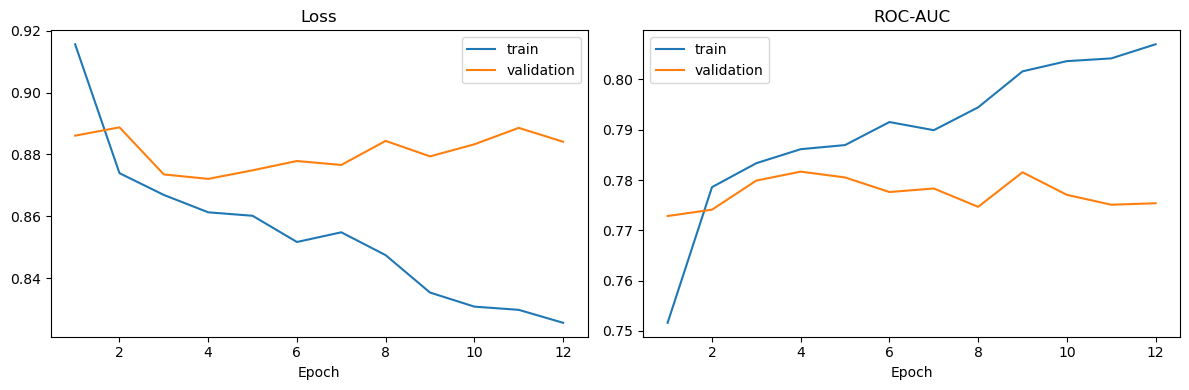

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_auc"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_auc"], label="validation")
axes[1].set_title("ROC-AUC")
axes[1].set_xlabel("Epoch")
axes[1].legend()

fig.tight_layout()
plt.show()

## Choose a Threshold

The model outputs probabilities. Because defaults are the minority class, `0.5` is not always the best threshold. Here we choose the validation threshold that maximizes F1 score.

In [28]:
y_val_true, y_val_prob = predict_proba(val_loader)
best_threshold = training_result["best_threshold"]

print("Best validation F1 threshold:", round(float(best_threshold), 3))
print("Best validation F1:", round(float(training_result["best_val_f1"]), 4))


Best validation F1 threshold: 0.54
Best validation F1: 0.5434


In [29]:
y_test_true, y_test_prob = predict_proba(test_loader)
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("Test ROC-AUC:", round(roc_auc_score(y_test_true, y_test_prob), 4))
print("Test PR-AUC:", round(average_precision_score(y_test_true, y_test_prob), 4))
print("Test accuracy:", round(accuracy_score(y_test_true, y_test_pred), 4))
print("Test F1:", round(f1_score(y_test_true, y_test_pred), 4))
print()
print(classification_report(y_test_true, y_test_pred, target_names=["no default", "default"]))
print("Confusion matrix:")
print(confusion_matrix(y_test_true, y_test_pred))


Test ROC-AUC: 0.7822
Test PR-AUC: 0.5588
Test accuracy: 0.7867
Test F1: 0.5407

              precision    recall  f1-score   support

  no default       0.87      0.85      0.86      3504
     default       0.52      0.57      0.54       996

    accuracy                           0.79      4500
   macro avg       0.69      0.71      0.70      4500
weighted avg       0.79      0.79      0.79      4500

Confusion matrix:
[[2975  529]
 [ 431  565]]


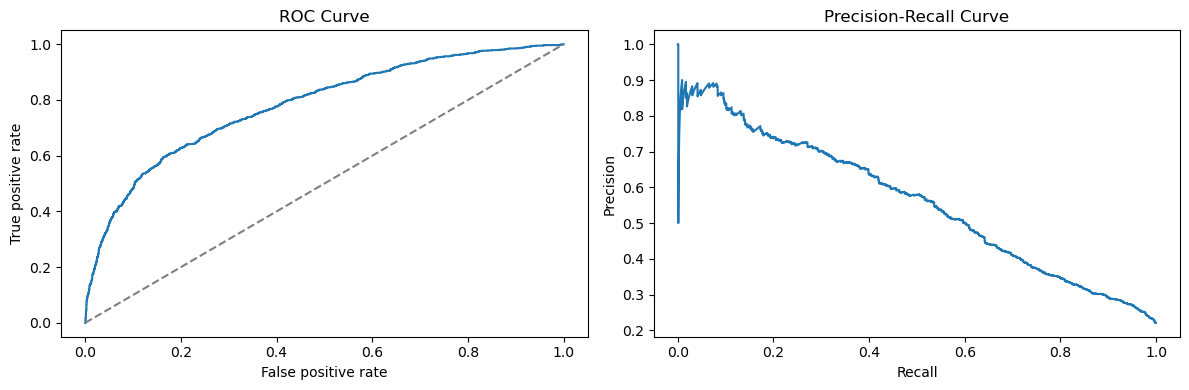

In [30]:
if "y_test_true" not in globals() or "y_test_prob" not in globals():
    y_test_true, y_test_prob = predict_proba(test_loader)

fpr, tpr, _ = roc_curve(y_test_true, y_test_prob)
precision, recall, _ = precision_recall_curve(y_test_true, y_test_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")

axes[1].plot(recall, precision)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

fig.tight_layout()
plt.show()

In [31]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_CONFIG_PATH = MODEL_DIR / "credit_default_mlp_config.json"
save_mlp_config(training_result["model_config"], MODEL_CONFIG_PATH)

model_artifact = {
    "model_state_dict": model.state_dict(),
    "input_dim": X_train.shape[1],
    "best_threshold": float(best_threshold),
    "feature_set": ACTIVE_FEATURE_SET,
    "use_feature_engineering": active_data["use_feature_engineering"],
    "engineered_cols": active_data["engineered_cols"],
    "categorical_cols": active_data["categorical_cols"],
    "numeric_cols": active_data["numeric_cols"],
    "model_config": training_result["model_config"],
    "training_config": {
        "seed": SEED,
        "batch_size": training_result["model_config"]["batch_size"],
        "max_epochs": DEFAULT_MAX_EPOCHS,
        "patience": DEFAULT_PATIENCE,
        "learning_rate": training_result["model_config"]["learning_rate"],
        "weight_decay": training_result["model_config"]["weight_decay"],
        "pos_weight": training_result["pos_weight"],
    },
    "history": training_result["history"],
    "validation_metrics": {
        "best_val_auc": training_result["best_val_auc"],
        "best_val_f1": training_result["best_val_f1"],
    },
}

torch.save(model_artifact, MODEL_DIR / "credit_default_mlp.pt")

print("Saved model to", MODEL_DIR / "credit_default_mlp.pt")
print("Saved feature set:", ACTIVE_FEATURE_SET)
print("Saved config to", MODEL_CONFIG_PATH)


Saved model to ../models/credit_default_mlp.pt
Saved feature set: engineered
Saved config to ../models/credit_default_mlp_config.json
